## 1. Class balance

In [22]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import random

random.seed(42)

data_root = Path("../data/raw")

rows = []

for split in ["train", "test"]:
    for cls in ["def_front", "ok_front"]:
        path = data_root / split / cls
        count = len(list(path.glob("*")))
        print(f"{split}/{cls}: {count}")

        for im in path.glob("*"):
            img = Image.open(im)
            gray = img.convert("L")
            arr = np.asarray(gray, dtype=np.float64)
            row = {
                "split": split,
                "class": cls,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "mean_px": arr.mean(),
                "std_px": arr.std(),
            }
            rows.append(row)


train/def_front: 3758
train/ok_front: 2875
test/def_front: 453
test/ok_front: 262


In [17]:
img_df = pd.DataFrame(rows)
print(img_df.shape)
img_df.head()

(7348, 7)


,split,class,width,height,mode,mean_px,std_px
0,train,def_front,300,300,RGB,152.461133,62.767939
1,train,def_front,300,300,RGB,141.844200,54.154159
2,train,def_front,300,300,RGB,138.020244,57.387111
3,train,def_front,300,300,RGB,154.651689,63.690401
4,train,def_front,300,300,RGB,138.613878,60.255102


### Findings
- Train: def_front=3758, ok_front=2875 (~57/43 split)
- Test: def_front=453, ok_front=262 (~63/37 split)
- Moderate imbalance, not severe. Decisions:
  - Use per-class precision/recall/F1 (or balanced accuracy) as the primary metric, not raw accuracy — a majority-class classifier already scores ~57-63%.
  - Consider class-weighted loss in training (Stage 3).
- Train/test imbalance ratios differ slightly — test isn't a perfectly stratified subset of train. Worth keeping in mind, not a blocker.

## 2. Image dimensions & pixel statistics

In [18]:
# Are all images the same size/mode?
img_df[["width", "height", "mode"]].drop_duplicates()

,width,height,mode
0,300,300,RGB


In [19]:
# Do the two classes differ in pixel intensity?
img_df.groupby(["split", "class"])[["mean_px", "std_px"]].describe()

mean_px                                                \
                  count        mean       std         min         25%   
split class                                                             
test  def_front   453.0  138.852397  5.558122  125.602856  135.150811   
      ok_front    262.0  148.879140  6.562513  132.233922  141.861236   
train def_front  3758.0  139.304465  5.837121  124.286322  135.160856   
      ok_front   2875.0  149.856345  6.466955  123.840700  143.115328   

                                                     std_px             \
                        50%         75%         max   count       mean   
split class                                                              
test  def_front  138.408378  141.991800  156.275967   453.0  58.281204   
      ok_front   151.292094  153.698928  158.659189   262.0  61.981048   
train def_front  138.893056  142.527017  157.016611  3758.0  58.610393   
      ok_front   151.939800  154.107189  160.617278  2875.0  62.294531   

                                                                       \
                      std        min        25%        50%        75%   
split class                                                             
test  def_front  3.091318  51.575420  55.799530  58.647348  60.414216   
      ok_front   2.608294  51.032802  59.971415  61.785862  63.839031   
train def_front  3.082920  51.545823  56.170844  59.030064  60.609400   
      ok_front   2.743604  49.638779  60.522986  62.073374  64.499918   

                            
                       max  
split class                 
test  def_front  68.419227  
      ok_front   66.842494  
train def_front  68.422486  
      ok_front   67.583266

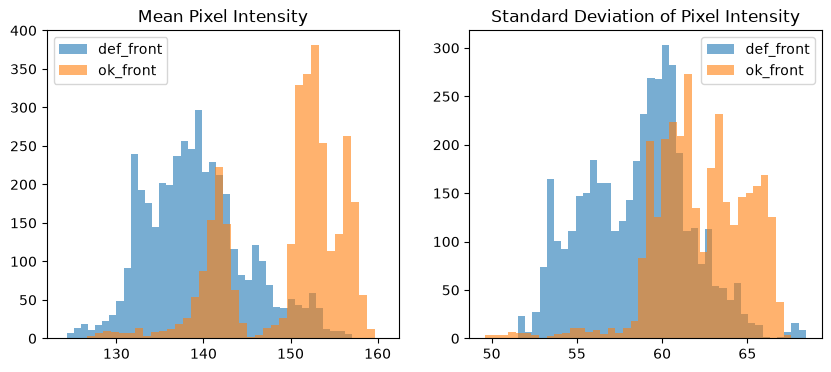

In [31]:
# Visualize the distribution of pixel intensity for each class
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for cls in ["def_front", "ok_front"]:
    subset = img_df[img_df["class"] == cls]
    axes[0].hist(subset["mean_px"], bins=40, alpha=0.6, label=cls)
    axes[1].hist(subset["std_px"], bins=40, alpha=0.6, label=cls)
axes[0].set_title("Mean Pixel Intensity")
axes[1].set_title("Standard Deviation of Pixel Intensity")
axes[0].legend()
axes[1].legend()
fig.savefig("../reports/figures/pixel_intensity_distribution.png", bbox_inches="tight")

### Findings
- All images uniform: 300×300, RGB. No corrupt/off-size files.
- Train/test are consistent per class (e.g. def_front mean_px ≈139.3 train vs ≈138.9 test; ok_front ≈149.9 vs ≈148.9) — no distribution shift between the two splits on this measure.
- def_front skews darker (def_front mean ≈139, ok_front mean ≈150), moderate overlap, physically sensible given that defects appear as dark regions.
- Contrast (std_px) heavily overlaps between classes, since defects in this dataset are subtle localized marks, not the type of thing that dramatically changes the overall contrast.
- Neither mean_px nor std_px cleanly separates the classes on its own (overlap zones in both histograms) — a simple brightness/contrast threshold wouldn't reliably classify these images. Supports the choice of a CNN in Stage 3, which can learn the spatial location of a defect rather than relying on whole-image statistics.

## 3. Sample Image grids

In [25]:
images_by_class = {}
for cls in ["def_front", "ok_front"]:
    path = data_root / "train" / cls
    images_by_class[cls] = list(path.glob("*"))
    print(f"train/{cls}: {len(images_by_class[cls])}")

train/def_front: 3758
train/ok_front: 2875


In [27]:
samples_by_class = {
    cls: random.sample(images_by_class[cls], k=9)
    for cls in images_by_class
}
print(samples_by_class["def_front"][:2])

[PosixPath('../data/raw/train/def_front/cast_def_0_4890.jpeg'), PosixPath('../data/raw/train/def_front/cast_def_0_6773.jpeg')]


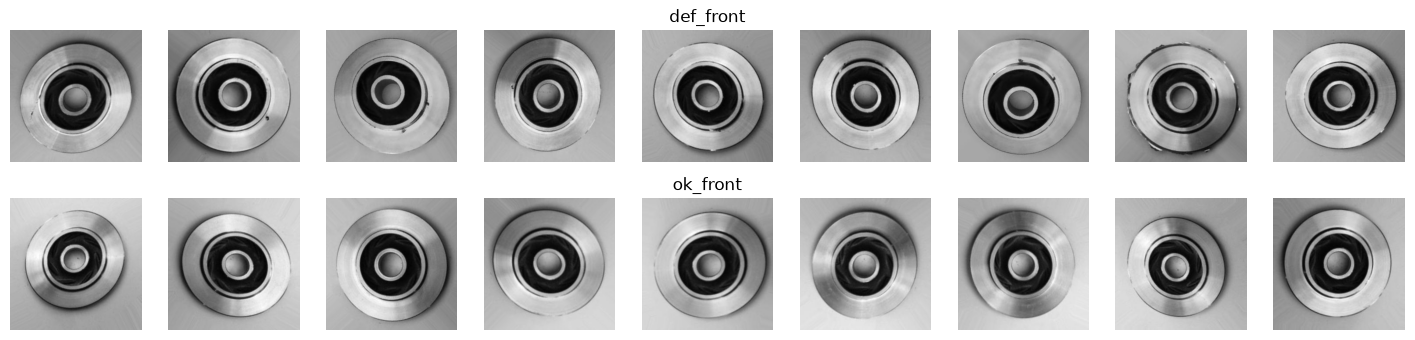

In [28]:
fig, axes = plt.subplots(2, 9, figsize=(18, 4))
for i, cls in enumerate(samples_by_class):
    for j, im_path in enumerate(samples_by_class[cls]):
        img = Image.open(im_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 4:
            axes[i, j].set_title(cls)

In [30]:
fig.savefig("../reports/figures/sample_grid.png", bbox_inches="tight")